In [ ]:
pip install "numpy<2"

In [ ]:
pip install ultralytics opencv-python

In [1]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

frame_data = []

for result in model("../data/videos/776148_7f042c3a_SL.mp4", stream=True):
    frame_info = {
        "frame": result.path,
        "detections": []
    }
    for box in result.boxes:
        frame_info["detections"].append({
            "class": model.names[int(box.cls)],
            "conf": float(box.conf),
            "bbox": box.xyxy[0].tolist()  # [x1, y1, x2, y2]
        })
    frame_data.append(frame_info)


video 1/1 (frame 1/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 7 persons, 1 baseball bat, 1 baseball glove, 2 chairs, 139.8ms
video 1/1 (frame 2/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 5 persons, 1 baseball bat, 1 baseball glove, 2 chairs, 39.3ms
video 1/1 (frame 3/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 7 persons, 2 baseball bats, 1 baseball glove, 2 chairs, 36.8ms
video 1/1 (frame 4/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 7 persons, 1 baseball bat, 1 baseball glove, 2 chairs, 36.8ms


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


video 1/1 (frame 5/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 7 persons, 2 baseball bats, 1 baseball glove, 2 chairs, 35.7ms
video 1/1 (frame 6/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 7 persons, 2 baseball bats, 1 baseball glove, 3 chairs, 44.5ms
video 1/1 (frame 7/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 6 persons, 2 baseball bats, 1 baseball glove, 3 chairs, 47.1ms
video 1/1 (frame 8/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x640 7 persons, 2 baseball bats, 1 baseball glove, 3 chairs, 38.1ms
video 1/1 (frame 9/810) /Users/apple/Documents/BU/Spring2026/CS585/Final-Project/Release-Point/scripts/../data/videos/776148_7f042c3a_SL.mp4: 384x64

In [2]:
import pandas as pd
import numpy as np

META_PATH = '../data/videos/metadata.csv'

df = pd.read_csv(META_PATH)

pitch = df[df['filename'] == '776148_7f042c3a_SL.mp4'].iloc[0]

print(pitch['release_pos_x'], pitch['release_pos_y'], pitch['release_pos_z'])
print(pitch['vx0'], pitch['vy0'], pitch['vz0'])
print(pitch['ax'], pitch['ay'], pitch['az'])


2.12 53.79 5.54
-9.10258819116116 -125.50509007747354 -6.058127446388792
-7.160706289704974 30.723868715448447 -31.09035359082394


In [3]:
def get_ball_position(t, pitch):
    x = pitch['release_pos_x'] + pitch['vx0']*t + 0.5*pitch['ax']*t**2
    y = pitch['release_pos_y'] + pitch['vy0']*t + 0.5*pitch['ay']*t**2
    z = pitch['release_pos_z'] + pitch['vz0']*t + 0.5*pitch['az']*t**2
    return x, y, z

# Generate positions across the pitch (~0.4-0.5 seconds flight time)
times = np.linspace(0, 0.45, 100)
trajectory = [get_ball_position(t, pitch) for t in times]
xs, ys, zs = zip(*trajectory)

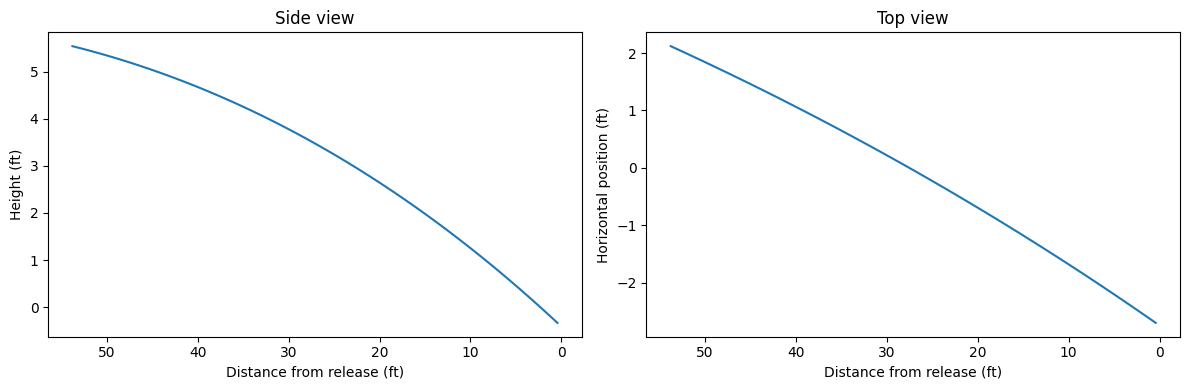

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Side view (y = distance from mound, z = height)
ax1.plot(ys, zs)
ax1.set_xlabel("Distance from release (ft)")
ax1.set_ylabel("Height (ft)")
ax1.set_title("Side view")
ax1.invert_xaxis()  # pitch travels toward negative y

# Top view
ax2.plot(ys, xs)
ax2.set_xlabel("Distance from release (ft)")
ax2.set_ylabel("Horizontal position (ft)")
ax2.set_title("Top view")
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

In [5]:
import cv2
import numpy as np

# Extract a single frame from your video to work with
cap = cv2.VideoCapture("../data/videos/776148_7f042c3a_SL.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # first frame
ret, frame = cap.read()
cap.release()

cv2.imwrite("frame0.png", frame)
print(f"Frame size: {frame.shape}")  # height x width x channels

Frame size: (720, 1280, 3)


In [14]:
import cv2
import numpy as np

points = []

def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        print(f"Point {len(points)}: ({x}, {y})")
        cv2.circle(img, (x, y), 5, (0, 255, 0), -1)
        cv2.imshow("frame", img)

img = cv2.imread("frame0.png")
cv2.imshow("frame", img)
cv2.setMouseCallback("frame", click_event)

print("Click these points IN ORDER:")
print("1. Pitcher's rubber - left edge")
print("2. Pitcher's rubber - right edge")
print("3. Home plate - front left corner")
print("4. Home plate - front right corner")
print("5. Home plate - back point (tip)")
print("\nPress 'q' when done")

cv2.waitKey(0)
cv2.destroyAllWindows()
print("Pixel points:", points)

Click these points IN ORDER:
1. Pitcher's rubber - left edge
2. Pitcher's rubber - right edge
3. Home plate - front left corner
4. Home plate - front right corner
5. Home plate - back point (tip)

Press 'q' when done
Point 1: (509, 635)
Point 2: (594, 636)
Point 3: (606, 368)
Point 4: (663, 369)
Point 5: (637, 365)
Pixel points: [(509, 635), (594, 636), (606, 368), (663, 369), (637, 365)]


In [15]:
import cv2
import numpy as np

# Real-world 3D coordinates (feet), origin = home plate center
# x = horizontal (positive = catcher's right/pitcher's left)
# y = distance from home plate (positive toward pitcher)
# z = height
world_pts = np.array([
    [-0.5,  60.5, 0.833],  # rubber left edge (1ft wide, 10in high)
    [ 0.5,  60.5, 0.833],  # rubber right edge
    [-0.708, 0.0, 0.0],    # home plate front left
    [ 0.708, 0.0, 0.0],    # home plate front right
    [ 0.0,  -0.708, 0.0],  # home plate back tip
], dtype=np.float32)

pixel_pts = np.array([
    [511, 634],
    [593, 637],
    [607, 368],
    [662, 368],
    [633, 361],
], dtype=np.float32)

# Estimate camera matrix (use frame size 1280x720)
h, w = 720, 1280
focal_length = w  # reasonable starting estimate
camera_matrix = np.array([
    [focal_length, 0, w/2],
    [0, focal_length, h/2],
    [0, 0, 1]
], dtype=np.float32)

dist_coeffs = np.zeros((4, 1))

# Solve for rotation and translation
success, rvec, tvec = cv2.solvePnP(
    world_pts, pixel_pts,
    camera_matrix, dist_coeffs,
    flags=cv2.SOLVEPNP_ITERATIVE
)

print("Success:", success)
print("Reprojection check:")

# Reproject world points back to pixels to check accuracy
projected, _ = cv2.projectPoints(world_pts, rvec, tvec, camera_matrix, dist_coeffs)
for i, (orig, proj) in enumerate(zip(pixel_pts, projected)):
    err = np.linalg.norm(orig - proj[0])
    print(f"  Point {i+1}: clicked={orig}, projected={proj[0].astype(int)}, error={err:.1f}px")

# Now project the ball trajectory onto the video
times = np.linspace(0, 0.45, 100)

# Use your pitch data
release_pos_x = -2.45  # from statcast (converted: plate_x units)
release_pos_y = 53.79  # release_pos_y from statcast
release_pos_z = 0.3236 # release_pos_z... wait, use actual values

# Paste your pitch row values here:
vx0, vy0, vz0 = -9.103, -125.505, -6.058
ax, ay, az    = -7.161,  30.724,  -31.090
release_x     =  2.12    # positive = pitcher's left (3rd base side)
release_y     =  53.79   # ft from home plate
release_z     =  5.54    # ft height — this was the bug

ball_3d = []
for t in times:
    x = release_x + vx0*t + 0.5*ax*t**2
    y = release_y + vy0*t + 0.5*ay*t**2
    z = release_z + vz0*t + 0.5*az*t**2
    ball_3d.append([x, y, z])

ball_3d = np.array(ball_3d, dtype=np.float32)

# Project trajectory to 2D pixels
ball_2d, _ = cv2.projectPoints(ball_3d, rvec, tvec, camera_matrix, dist_coeffs)
ball_2d = ball_2d.reshape(-1, 2).astype(int)

# Draw on frame
img = cv2.imread("frame0.png")
for pt in ball_2d:
    if 0 <= pt[0] < w and 0 <= pt[1] < h:
        cv2.circle(img, tuple(pt), 4, (0, 0, 255), -1)

cv2.imwrite("trajectory_overlay.png", img)
print("\nSaved trajectory_overlay.png")

Success: True
Reprojection check:
  Point 1: clicked=[        511         634], projected=[510 634], error=0.9px
  Point 2: clicked=[        593         637], projected=[593 636], error=0.9px
  Point 3: clicked=[        607         368], projected=[621 365], error=15.2px
  Point 4: clicked=[        662         368], projected=[645 366], error=16.2px
  Point 5: clicked=[        633         361], projected=[634 365], error=4.5px

Saved trajectory_overlay.png


In [ ]:
# First, print ALL the relevant statcast values for this pitch
pitch = df[df['filename'] == '776148_7f042c3a_SL.mp4'].iloc[0]
cols = ['release_pos_x', 'release_pos_y', 'release_pos_z', 
        'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az',
        'plate_x', 'plate_z']
for c in cols:
    print(f"{c}: {pitch[c]}")

release_pos_x: 2.12
release_pos_y: 53.79
release_pos_z: 5.54
vx0: -9.10258819116116
vy0: -125.50509007747354
vz0: -6.058127446388792
ax: -7.160706289704974
ay: 30.723868715448447
az: -31.09035359082394
plate_x: -2.45546584848882
plate_z: 0.3236869973168463


: 